<a href="https://colab.research.google.com/github/nadineashmawey/arabic-sign-language-recognition/blob/main/01_Arabic_sign_language.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In this section, we load and inspect the Arabic Sign Language dataset
before applying preprocessing or training a machine learning model.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [103]:
import os
import glob
import shutil
MODEL_DIR = "/content/drive/MyDrive/ArabicSignProject/models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Models will be saved to:", MODEL_DIR)

Models will be saved to: /content/drive/MyDrive/ArabicSignProject/models


In [5]:
!pip install -q -U kagglehub

In [6]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "muhammadalbrham/rgb-arabic-alphabets-sign-language-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'rgb-arabic-alphabets-sign-language-dataset' dataset.
Dataset downloaded to:
/kaggle/input/rgb-arabic-alphabets-sign-language-dataset


In [7]:
import os

print(os.listdir(dataset_path))

['RGB ArSL dataset']


In [8]:
data_dir = os.path.join(dataset_path, "RGB ArSL dataset")

print(os.listdir(data_dir))

['Zain', 'Zah', 'Meem', 'Seen', 'Teh', 'Lam', 'Dad', 'Teh_Marbuta', 'Reh', 'Sad', 'Dal', 'Sheen', 'Hah', 'Beh', 'Tah', 'Alef', 'Waw', 'Qaf', 'Al', 'Ghain', 'Heh', 'Ain', 'Kaf', 'Thal', 'Feh', 'Khah', 'Yeh', 'Jeem', 'Theh', 'Noon', 'Laa']


In [9]:
#checking whether the dataset is imbalanced
class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print(class_counts)

{'Zain': 201, 'Zah': 232, 'Meem': 253, 'Seen': 266, 'Teh': 311, 'Lam': 260, 'Dad': 266, 'Teh_Marbuta': 257, 'Reh': 227, 'Sad': 270, 'Dal': 235, 'Sheen': 278, 'Hah': 246, 'Beh': 307, 'Tah': 226, 'Alef': 287, 'Waw': 249, 'Qaf': 219, 'Al': 276, 'Ghain': 230, 'Heh': 253, 'Ain': 244, 'Kaf': 264, 'Thal': 202, 'Feh': 255, 'Khah': 250, 'Yeh': 272, 'Jeem': 210, 'Theh': 305, 'Noon': 237, 'Laa': 268}


The dataset contains 31 sign classes with approximately 200–310 images per class, indicating a relatively balanced class distribution.

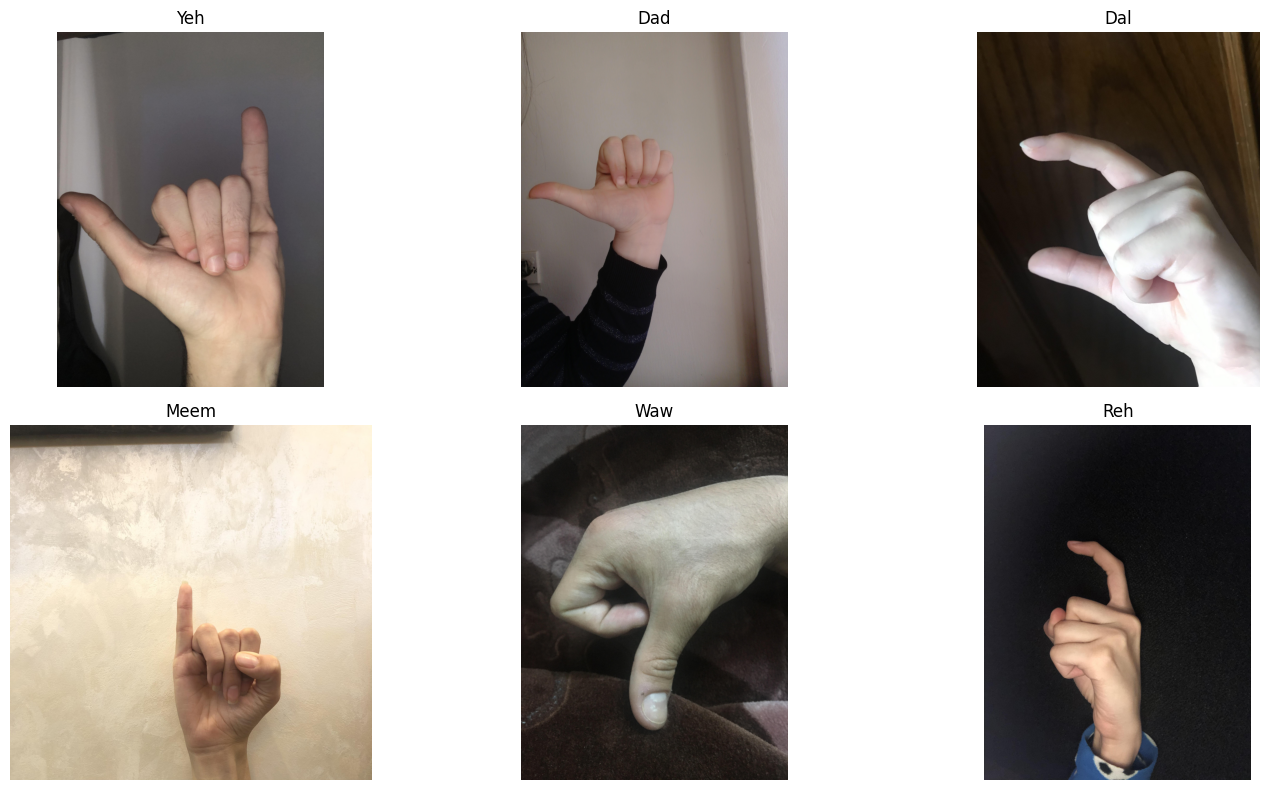

In [10]:
import random
import cv2

selected_classes = random.sample(list(class_counts.keys()), 6)

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(selected_classes):
    class_path = os.path.join(data_dir, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
print("Image shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())

Image shape: (3088, 2320, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [12]:
#checking resolution of different image samples
for i in range(10):
    class_name = random.choice(list(class_counts.keys()))
    class_path = os.path.join(data_dir, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    img = cv2.imread(image_path)

    print(class_name, "->", img.shape)

Al -> (4608, 3456, 3)
Reh -> (3968, 2976, 3)
Theh -> (3088, 2320, 3)
Heh -> (2486, 2059, 3)
Hah -> (3264, 2448, 3)
Qaf -> (4032, 3024, 3)
Seen -> (4608, 3456, 3)
Heh -> (2014, 1510, 3)
Jeem -> (4032, 3024, 3)
Qaf -> (4032, 3024, 3)


we will use 224 * 224 * 3 image resolution , so we need to resize all images to this size

In [13]:
#testing padding to avoid squashing the hand pictures

resized_image = tf.image.resize_with_pad(
    image,
    target_height=224,
    target_width=224
)

print("Original shape:", image.shape)
print("New shape:", resized_image.shape)

Original shape: (3088, 2320, 3)
New shape: (224, 224, 3)


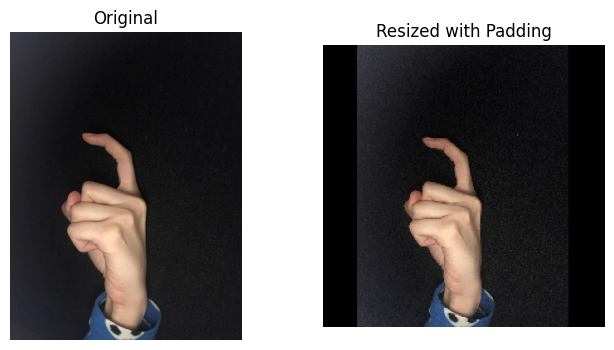

In [14]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.cast(resized_image, tf.uint8))
plt.title("Resized with Padding")
plt.axis("off")

plt.show()

the shape of the fingers and hand is extremely important for sign classification

In [15]:
classes_to_check = ["Alef", "Beh", "Teh"]

for class_name in classes_to_check:
    class_path = os.path.join(data_dir, class_name)

    print(f"\n{class_name}:")
    print(os.listdir(class_path)[:10])


Alef:
['Alef_161.jpg', 'Alef_282.jpg', 'Alef_219.jpg', 'Alef_256.jpg', 'Alef_107.jpg', 'Alef_213.jpg', 'Alef_97.jpg', 'Alef_80.jpeg', 'Alef_278.jpeg', 'Alef_16.jpg']

Beh:
['Beh_175.jpg', 'Beh_289.jpg', 'Beh_70.jpg', 'Beh_292.jpeg', 'Beh_47.jpg', 'Beh_35.jpg', 'Beh_199.jpg', 'Beh_103.jpeg', 'Beh_34.jpeg', 'Beh_96.jpg']

Teh:
['Teh_217.jpg', 'Teh_39.jpg', 'Teh_268.jpg', 'Teh_142.jpg', 'Teh_91.jpg', 'Teh_154.jpeg', 'Teh_96.jpeg', 'Teh_293.jpg', 'Teh_102.jpg', 'Teh_251.jpg']


we will use stratified split 70% training
                     15% validation
                     15% testing , since stratification tries to preserve the class proportions

In [16]:
import pandas as pd

filepaths = []
labels = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            filepaths.append(image_path)
            labels.append(class_name)

data = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

data.head()

,filepath,label
0,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
1,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
2,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
3,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
4,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain


In [17]:
print("Total images:", len(data))
print("Number of classes:", data["label"].nunique())

data.head()

Total images: 7856
Number of classes: 31


,filepath,label
0,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
1,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
2,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
3,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain
4,/kaggle/input/rgb-arabic-alphabets-sign-langua...,Zain


In [18]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42,
    stratify=data["label"]
)

In [19]:
val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=42,
    stratify=temp_data["label"]
)

In [20]:
print("Training images:", len(train_data))
print("Validation images:", len(val_data))
print("Testing images:", len(test_data))

Training images: 5499
Validation images: 1178
Testing images: 1179


In [21]:
#making sure splits are stratified
print("TRAIN")
print(train_data["label"].value_counts(normalize=True).head())

print("\nVALIDATION")
print(val_data["label"].value_counts(normalize=True).head())

print("\nTEST")
print(test_data["label"].value_counts(normalize=True).head())

TRAIN
label
Teh      0.039644
Beh      0.039098
Theh     0.038734
Alef     0.036552
Sheen    0.035461
Name: proportion, dtype: float64

VALIDATION
label
Theh    0.039049
Beh     0.039049
Teh     0.039049
Alef    0.036503
Al      0.034805
Name: proportion, dtype: float64

TEST
label
Teh     0.039864
Theh    0.039016
Beh     0.039016
Alef    0.036472
Al      0.035623
Name: proportion, dtype: float64


In [22]:
class_names = sorted(data["label"].unique())

print(class_names)
print("Number of classes:", len(class_names))

['Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh', 'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh', 'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh', 'Waw', 'Yeh', 'Zah', 'Zain']
Number of classes: 31


In [23]:
#label encoding
label_to_index = {
    label: index
    for index, label in enumerate(class_names)
}

print(label_to_index)

{'Ain': 0, 'Al': 1, 'Alef': 2, 'Beh': 3, 'Dad': 4, 'Dal': 5, 'Feh': 6, 'Ghain': 7, 'Hah': 8, 'Heh': 9, 'Jeem': 10, 'Kaf': 11, 'Khah': 12, 'Laa': 13, 'Lam': 14, 'Meem': 15, 'Noon': 16, 'Qaf': 17, 'Reh': 18, 'Sad': 19, 'Seen': 20, 'Sheen': 21, 'Tah': 22, 'Teh': 23, 'Teh_Marbuta': 24, 'Thal': 25, 'Theh': 26, 'Waw': 27, 'Yeh': 28, 'Zah': 29, 'Zain': 30}


In [24]:
train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_data.copy()

train_data["label_id"] = train_data["label"].map(label_to_index)
val_data["label_id"] = val_data["label"].map(label_to_index)
test_data["label_id"] = test_data["label"].map(label_to_index)

In [25]:
#processing one image
IMG_SIZE = 224

def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize_with_pad(
        image,
        IMG_SIZE,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label

In [26]:
def create_dataset(dataframe, shuffle=False):

    filepaths = dataframe["filepath"].values
    labels = dataframe["label_id"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(32)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [27]:
train_ds = create_dataset(train_data, shuffle=True)

val_ds = create_dataset(val_data)

test_ds = create_dataset(test_data)

In [28]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

    print("\nFirst 10 labels:")
    print(labels[:10].numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)

First 10 labels:
[24  2 17 22  3 21  9 28 27 10]


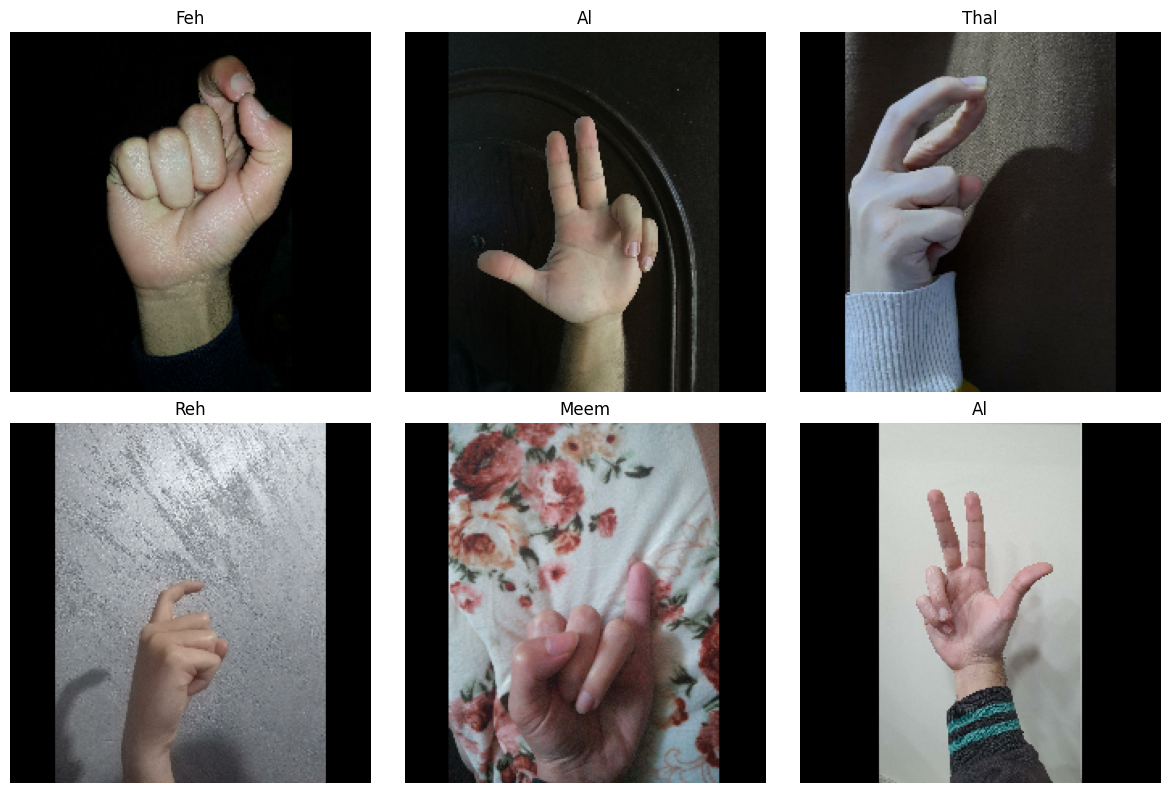

In [29]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(6):

        plt.subplot(2, 3, i + 1)

        plt.imshow(
            tf.cast(images[i], tf.uint8)
        )

        label_number = labels[i].numpy()

        plt.title(
            class_names[label_number]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

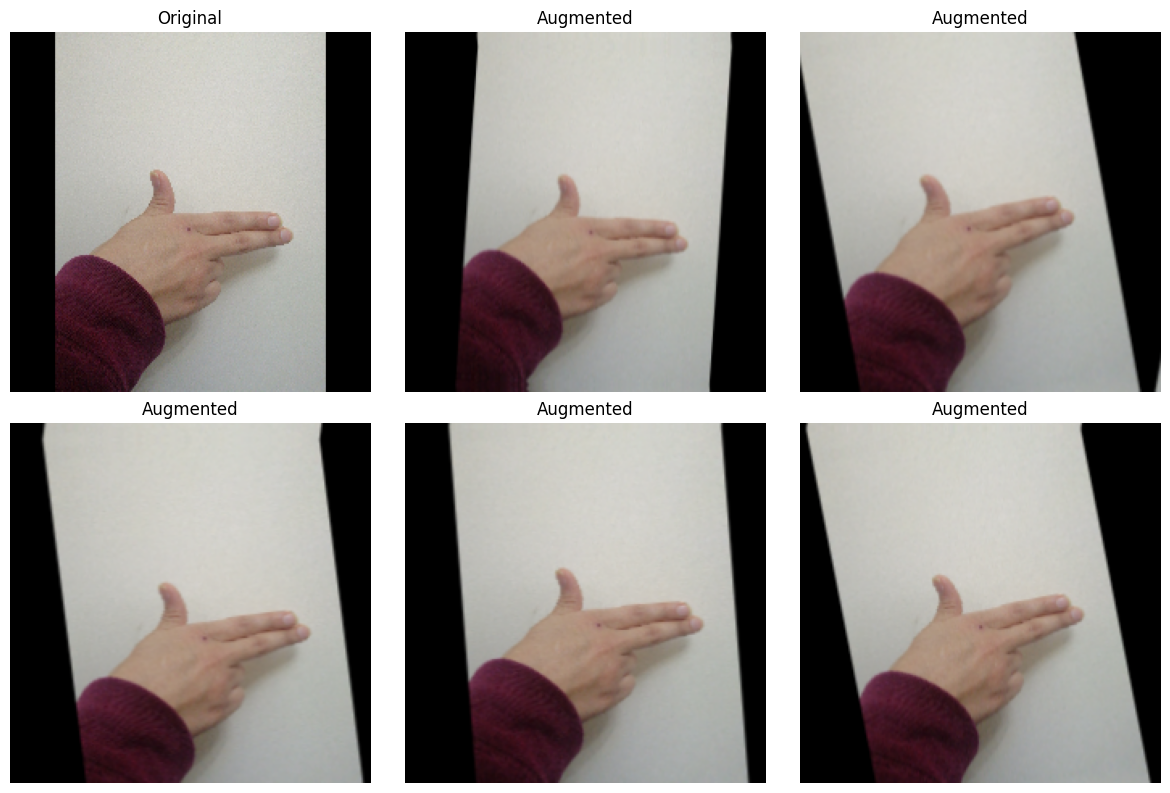

In [31]:
for images, labels in train_ds.take(1):

    original = images[0]

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(tf.cast(original, tf.uint8))
    plt.title("Original")
    plt.axis("off")

    for i in range(5):
        augmented = data_augmentation(
            tf.expand_dims(original, 0),
            training=True
        )

        plt.subplot(2, 3, i + 2)
        plt.imshow(
            tf.cast(augmented[0], tf.uint8)
        )
        plt.title("Augmented")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [32]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [33]:
base_model.trainable = False

In [34]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

In [35]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 31)             │        39,711 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,297,695 (8.77 MB)

 Trainable params: 39,711 (155.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [38]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.1993 - loss: 2.9220 - val_accuracy: 0.3812 - val_loss: 2.1267
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.3995 - loss: 2.0479 - val_accuracy: 0.4457 - val_loss: 1.8297
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.4946 - loss: 1.6975 - val_accuracy: 0.4805 - val_loss: 1.6828
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.5417 - loss: 1.5383 - val_accuracy: 0.5238 - val_loss: 1.5223
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.5706 - loss: 1.4223 - val_accuracy: 0.4864 - val_loss: 1.5849


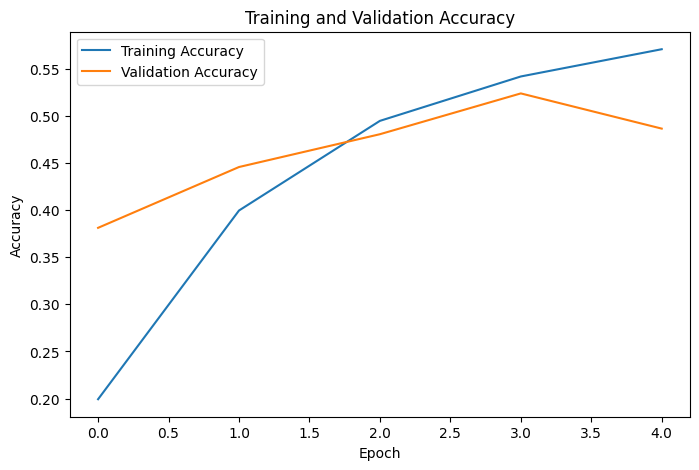

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

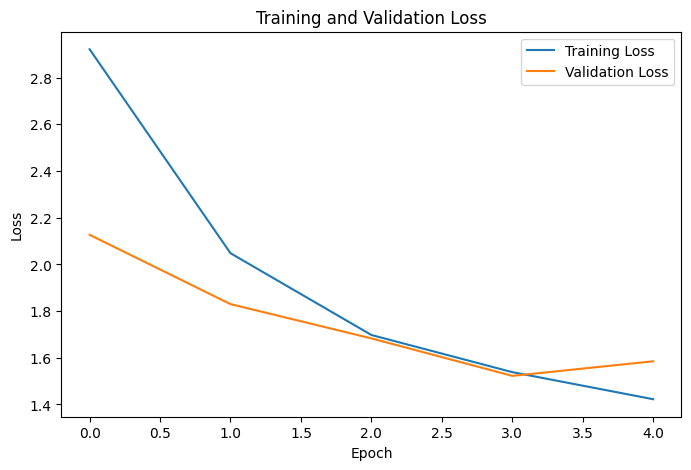

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [41]:
model.save("arabic_sign_before_finetuning.keras")

In [42]:
base_model.trainable = True

In [43]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [45]:
fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_finetuned_arabic_sign_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [46]:
fine_tune_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

In [47]:
fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [48]:
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stop,
        fine_tune_reduce_lr
    ]
)

Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4064 - loss: 1.9858
Epoch 1: val_accuracy improved from None to 0.55688, saving model to best_finetuned_arabic_sign_model.keras

Epoch 1: finished saving model to best_finetuned_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.4537 - loss: 1.8149 - val_accuracy: 0.5569 - val_loss: 1.4104 - learning_rate: 1.0000e-05
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5660 - loss: 1.4385
Epoch 2: val_accuracy improved from 0.55688 to 0.58065, saving model to best_finetuned_arabic_sign_model.keras

Epoch 2: finished saving model to best_finetuned_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.5803 - loss: 1.3667 - val_accuracy: 0.5806 - val_loss: 1.2953 - learning_rate: 1.0000e-05
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6358 - loss: 1.1965
Epoch 3: val_accuracy improved from 0.58065 to 0.61460, saving model to best_finetuned

In [49]:
history_ft2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=15,
    epochs=20,
    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stop,
        fine_tune_reduce_lr
    ]
)

Epoch 16/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8660 - loss: 0.4213
Epoch 16: val_accuracy improved from 0.80306 to 0.80645, saving model to best_finetuned_arabic_sign_model.keras

Epoch 16: finished saving model to best_finetuned_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.8725 - loss: 0.4175 - val_accuracy: 0.8065 - val_loss: 0.6110 - learning_rate: 1.0000e-05
Epoch 17/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8761 - loss: 0.4057
Epoch 17: val_accuracy did not improve from 0.80645
172/172 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.8738 - loss: 0.4063 - val_accuracy: 0.8065 - val_loss: 0.6033 - learning_rate: 1.0000e-05
Epoch 18/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8729 - loss: 0.4069
Epoch 18: val_accuracy improved from 0.80645 to 0.81070, saving model to best_finetuned_arabic_sign_model.keras

Epoch 18: finished saving model to best_finetuned_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━

In [50]:
model.save("arabic_sign_stage1_80percent.keras")

In [51]:
base_model.trainable = True

# Freeze everything except the last 60 layers
for layer in base_model.layers[:-60]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [52]:
trainable_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print("Number of trainable MobileNetV2 layers:",
      len(trainable_layers))

print("\nLast trainable layers:")
print(trainable_layers[-10:])

Number of trainable MobileNetV2 layers: 19

Last trainable layers:
['block_15_depthwise_relu', 'block_15_project', 'block_15_add', 'block_16_expand', 'block_16_expand_relu', 'block_16_depthwise', 'block_16_depthwise_relu', 'block_16_project', 'Conv_1', 'out_relu']


In [53]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [54]:
stage2_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_stage2_arabic_sign_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

stage2_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

stage2_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [55]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=20,
    epochs=30,
    callbacks=[
        stage2_checkpoint,
        stage2_early_stop,
        stage2_reduce_lr
    ]
)

Epoch 21/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9098 - loss: 0.2914
Epoch 21: val_accuracy improved from None to 0.81070, saving model to best_stage2_arabic_sign_model.keras

Epoch 21: finished saving model to best_stage2_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9069 - loss: 0.2882 - val_accuracy: 0.8107 - val_loss: 0.5517 - learning_rate: 5.0000e-06
Epoch 22/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9172 - loss: 0.2600
Epoch 22: val_accuracy improved from 0.81070 to 0.81239, saving model to best_stage2_arabic_sign_model.keras

Epoch 22: finished saving model to best_stage2_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9202 - loss: 0.2553 - val_accuracy: 0.8124 - val_loss: 0.5500 - learning_rate: 5.0000e-06
Epoch 23/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9156 - loss: 0.2648
Epoch 23: val_accuracy improved from 0.81239 to 0.82003, saving model to best_stage2_arabic

In [56]:
best_model = tf.keras.models.load_model(
    "best_stage2_arabic_sign_model.keras"
)

In [57]:
import numpy as np

y_val_true = np.concatenate([
    labels.numpy()
    for images, labels in val_ds
])

In [58]:
y_val_prob = best_model.predict(val_ds)

y_val_pred = np.argmax(
    y_val_prob,
    axis=1
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step


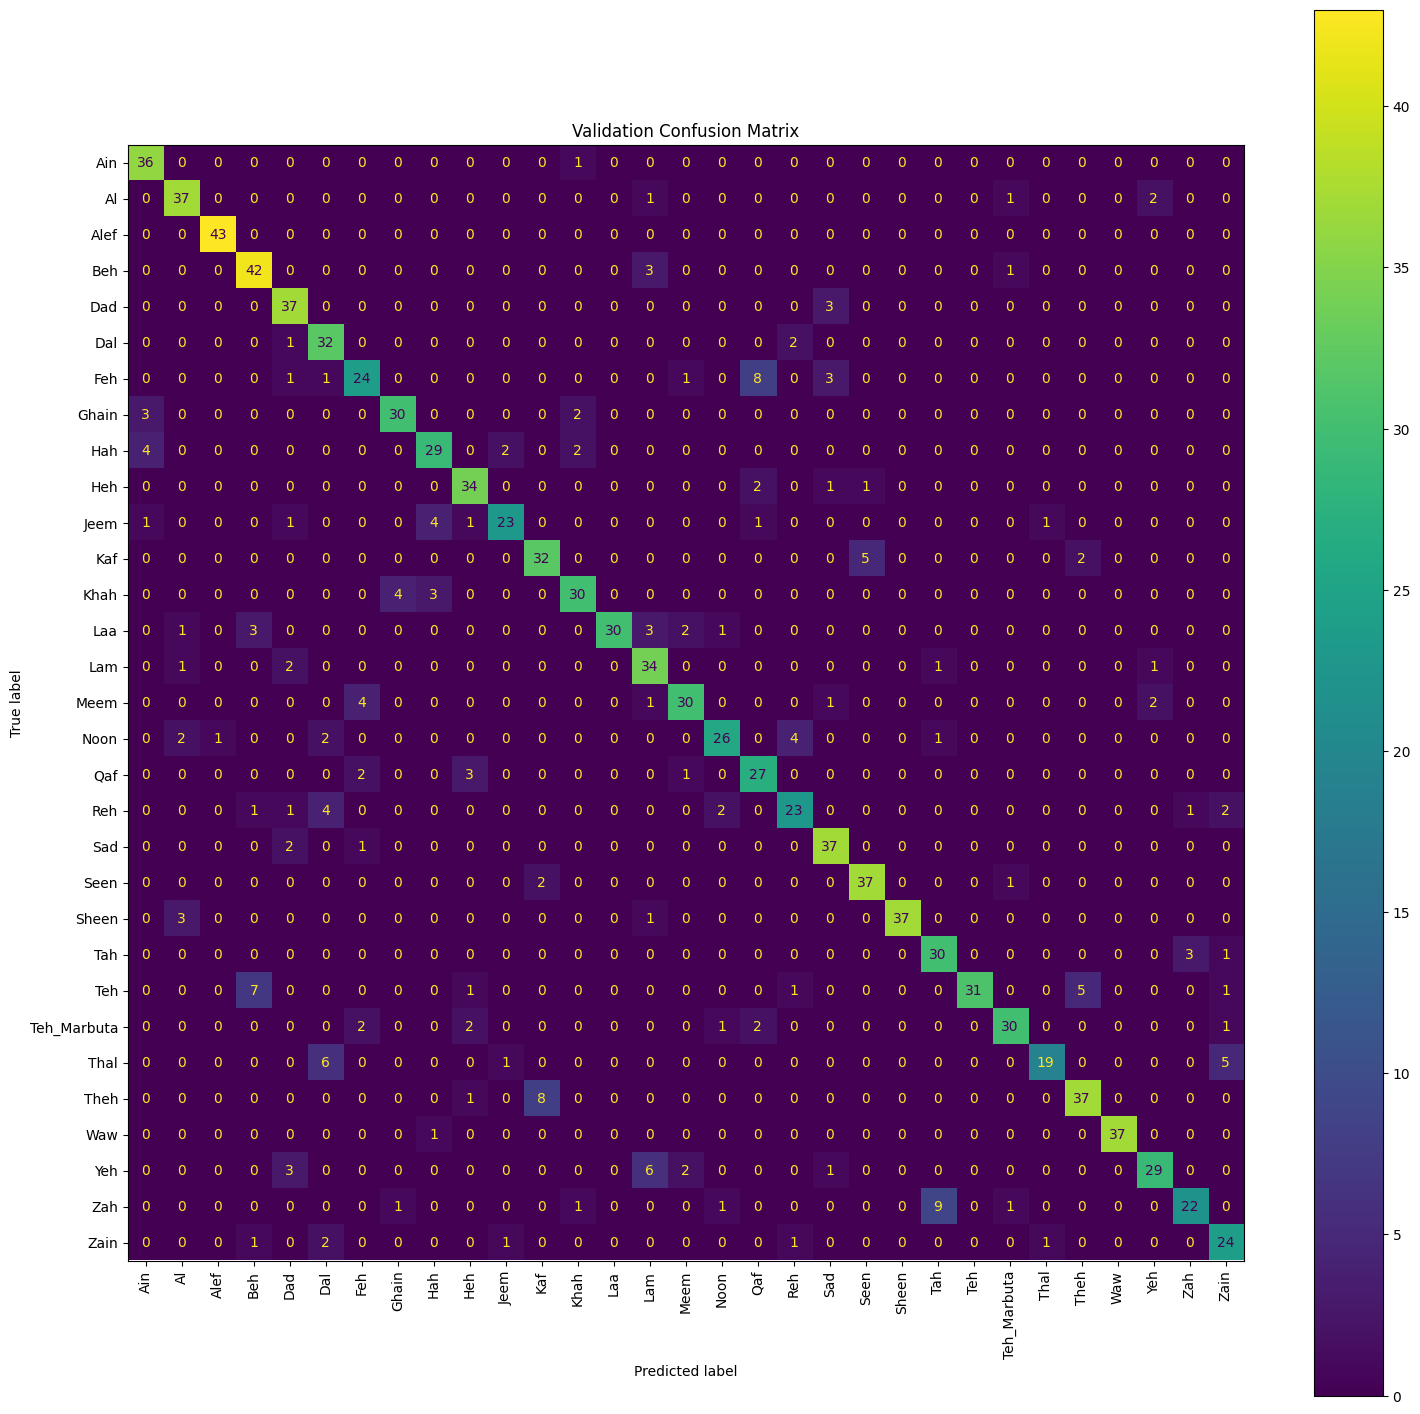

In [59]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val_true,
    y_val_pred
)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Validation Confusion Matrix")
plt.show()

In [60]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

class_results = pd.DataFrame({
    "Class": class_names,
    "Accuracy": per_class_accuracy
})

class_results["Accuracy_Percent"] = (
    class_results["Accuracy"] * 100
)

class_results = class_results.sort_values(
    "Accuracy"
)

print(class_results[
    ["Class", "Accuracy_Percent"]
].to_string(index=False))

      Class  Accuracy_Percent
       Thal         61.290323
        Zah         62.857143
        Feh         63.157895
        Teh         67.391304
        Reh         67.647059
        Yeh         70.731707
       Jeem         71.875000
       Noon         72.222222
        Laa         75.000000
        Hah         78.378378
       Meem         78.947368
Teh_Marbuta         78.947368
       Zain         80.000000
       Theh         80.434783
       Khah         81.081081
        Qaf         81.818182
        Kaf         82.051282
      Ghain         85.714286
        Lam         87.179487
        Tah         88.235294
        Heh         89.473684
         Al         90.243902
      Sheen         90.243902
        Beh         91.304348
        Dal         91.428571
       Seen         92.500000
        Dad         92.500000
        Sad         92.500000
        Ain         97.297297
        Waw         97.368421
       Alef        100.000000


In [61]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

confusions = []

for actual_id in range(len(class_names)):
    for predicted_id in range(len(class_names)):
        count = cm_errors[actual_id, predicted_id]

        if count > 0:
            confusions.append({
                "Actual": class_names[actual_id],
                "Predicted": class_names[predicted_id],
                "Count": count
            })

confusions_df = pd.DataFrame(confusions)

confusions_df = confusions_df.sort_values(
    "Count",
    ascending=False
)

print(confusions_df.head(20).to_string(index=False))

Actual Predicted  Count
   Zah       Tah      9
  Theh       Kaf      8
   Feh       Qaf      8
   Teh       Beh      7
  Thal       Dal      6
   Yeh       Lam      6
   Kaf      Seen      5
  Thal      Zain      5
   Teh      Theh      5
  Noon       Reh      4
  Khah     Ghain      4
  Jeem       Hah      4
   Hah       Ain      4
  Meem       Feh      4
   Reh       Dal      4
  Khah       Hah      3
 Ghain       Ain      3
   Yeh       Dad      3
   Laa       Lam      3
 Sheen        Al      3


In [62]:
!pip install -q -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 39.3 MB/s eta 0:00:00


In [63]:
from huggingface_hub import hf_hub_download
import importlib.util
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Download OpenCV palm detector model
palm_model_path = hf_hub_download(
    repo_id="opencv/palm_detection_mediapipe",
    filename="palm_detection_mediapipe_2023feb.onnx"
)

# Download OpenCV's Python wrapper
palm_code_path = hf_hub_download(
    repo_id="opencv/palm_detection_mediapipe",
    filename="mp_palmdet.py"
)

print("Downloaded!")

palm_detection_mediapipe_2023feb.onnx: reconstructing file:   0%|          |  0.00B / 3.91MB            

palm_detection_mediapipe_2023feb.onnx: downloading bytes:           |  0.00B            

mp_palmdet.py:   0%|          | 0.00/93.6k [00:00<?, ?B/s]

Downloaded!


In [64]:
spec = importlib.util.spec_from_file_location(
    "mp_palmdet",
    palm_code_path
)

mp_palmdet = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mp_palmdet)

MPPalmDet = mp_palmdet.MPPalmDet

In [65]:
palm_detector = MPPalmDet(
    modelPath=palm_model_path,
    nmsThreshold=0.3,
    scoreThreshold=0.5,
    topK=1,
    backendId=cv2.dnn.DNN_BACKEND_OPENCV,
    targetId=cv2.dnn.DNN_TARGET_CPU
)

print("Palm detector ready!")

Palm detector ready!


In [66]:
def crop_hand(image_path, scale=3.0):

    image = cv2.imread(image_path)

    if image is None:
        return None

    h, w, _ = image.shape

    palms = palm_detector.infer(image)

    # If no palm detected, use original image
    if palms is None or len(palms) == 0:
        return image

    # Pick detection with highest confidence
    palm = max(
        palms,
        key=lambda detection: detection[-1]
    )

    x1, y1, x2, y2 = palm[:4]

    # Palm centre
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    palm_width = x2 - x1
    palm_height = y2 - y1

    # Make a larger square so fingers are included
    size = max(palm_width, palm_height) * scale

    new_x1 = int(center_x - size / 2)
    new_x2 = int(center_x + size / 2)

    new_y1 = int(center_y - size / 2)
    new_y2 = int(center_y + size / 2)

    # Keep crop inside image
    new_x1 = max(0, new_x1)
    new_y1 = max(0, new_y1)

    new_x2 = min(w, new_x2)
    new_y2 = min(h, new_y2)

    cropped = image[
        new_y1:new_y2,
        new_x1:new_x2
    ]

    return cropped

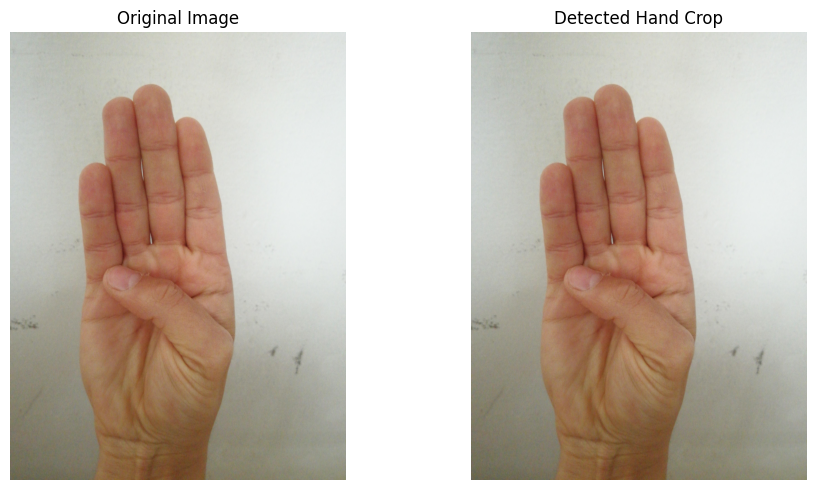

In [67]:
sample_path = train_data.iloc[0]["filepath"]

original = cv2.imread(sample_path)
cropped = crop_hand(sample_path)

original_rgb = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

cropped_rgb = cv2.cvtColor(
    cropped,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_rgb)
plt.title("Detected Hand Crop")
plt.axis("off")

plt.tight_layout()
plt.show()

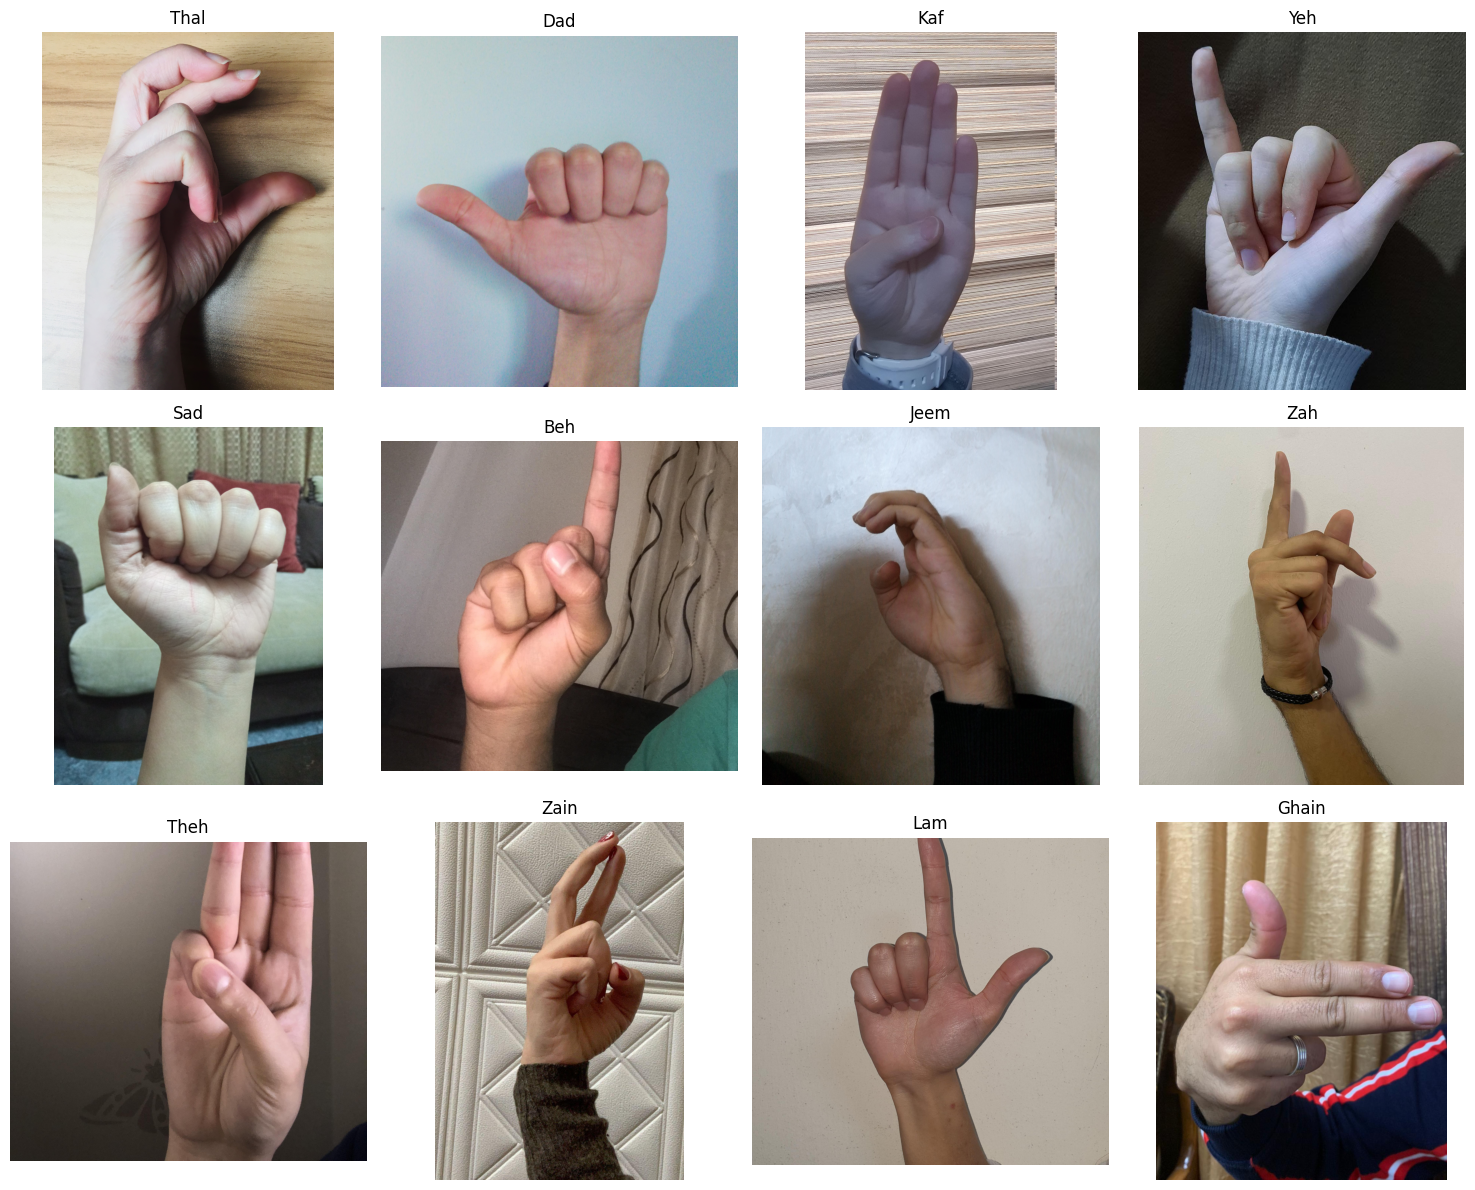

In [68]:
samples = train_data.sample(12, random_state=42)

plt.figure(figsize=(15, 12))

for i, (_, row) in enumerate(samples.iterrows()):

    cropped = crop_hand(row["filepath"])

    cropped_rgb = cv2.cvtColor(
        cropped,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(3, 4, i + 1)
    plt.imshow(cropped_rgb)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [69]:
def crop_hand_with_status(image_path, scale=3.0):

    image = cv2.imread(image_path)

    if image is None:
        return None, False

    h, w, _ = image.shape

    palms = palm_detector.infer(image)

    # No hand detected
    if palms is None or len(palms) == 0:
        return image, False

    palm = max(
        palms,
        key=lambda detection: detection[-1]
    )

    x1, y1, x2, y2 = palm[:4]

    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    palm_width = x2 - x1
    palm_height = y2 - y1

    size = max(
        palm_width,
        palm_height
    ) * scale

    new_x1 = int(center_x - size / 2)
    new_x2 = int(center_x + size / 2)

    new_y1 = int(center_y - size / 2)
    new_y2 = int(center_y + size / 2)

    new_x1 = max(0, new_x1)
    new_y1 = max(0, new_y1)

    new_x2 = min(w, new_x2)
    new_y2 = min(h, new_y2)

    cropped = image[
        new_y1:new_y2,
        new_x1:new_x2
    ]

    return cropped, True

In [70]:
from tqdm.auto import tqdm
import os

CROPPED_DIR = "/content/cropped_arsl"

os.makedirs(CROPPED_DIR, exist_ok=True)

In [71]:
def create_cropped_split(dataframe, split_name):

    new_data = dataframe.copy()

    cropped_paths = []
    detection_results = []

    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe),
        desc=split_name
    ):

        label = row["label"]
        original_path = row["filepath"]

        output_folder = os.path.join(
            CROPPED_DIR,
            split_name,
            label
        )

        os.makedirs(
            output_folder,
            exist_ok=True
        )

        filename = os.path.basename(
            original_path
        )

        output_path = os.path.join(
            output_folder,
            filename
        )

        cropped, detected = crop_hand_with_status(
            original_path
        )

        if cropped is not None:

            cv2.imwrite(
                output_path,
                cropped,
                [cv2.IMWRITE_JPEG_QUALITY, 95]
            )

            cropped_paths.append(
                output_path
            )

            detection_results.append(
                detected
            )

    new_data["filepath"] = cropped_paths
    new_data["hand_detected"] = detection_results

    return new_data

In [72]:
print("crop_hand_with_status exists:",
      "crop_hand_with_status" in globals())

print("create_cropped_split exists:",
      "create_cropped_split" in globals())

crop_hand_with_status exists: True
create_cropped_split exists: True


In [73]:
cropped_train_data = create_cropped_split(
    train_data,
    "train"
)

train:   0%|          | 0/5499 [00:00<?, ?it/s]

In [74]:
cropped_val_data = create_cropped_split(
    val_data,
    "validation"
)

validation:   0%|          | 0/1178 [00:00<?, ?it/s]

In [75]:
cropped_test_data = create_cropped_split(
    test_data,
    "test"
)

test:   0%|          | 0/1179 [00:00<?, ?it/s]

In [76]:
print(
    "Train detection rate:",
    cropped_train_data["hand_detected"].mean() * 100
)

print(
    "Validation detection rate:",
    cropped_val_data["hand_detected"].mean() * 100
)

print(
    "Test detection rate:",
    cropped_test_data["hand_detected"].mean() * 100
)

Train detection rate: 89.87088561556646
Validation detection rate: 90.2376910016978
Test detection rate: 90.50042408821035


In [77]:
failure_by_class = (
    cropped_train_data
    .groupby("label")["hand_detected"]
    .agg(["mean", "count"])
)

failure_by_class["Detection_Percent"] = (
    failure_by_class["mean"] * 100
)

failure_by_class = failure_by_class.sort_values(
    "Detection_Percent"
)

print(
    failure_by_class[
        ["Detection_Percent", "count"]
    ].to_string()
)

             Detection_Percent  count
label                                
Khah                 72.000000    175
Waw                  73.563218    174
Hah                  73.837209    172
Heh                  77.966102    177
Jeem                 83.673469    147
Teh_Marbuta          87.777778    180
Reh                  88.679245    159
Feh                  88.826816    179
Qaf                  88.888889    153
Dal                  89.090909    165
Theh                 89.671362    213
Teh                  89.908257    218
Ain                  90.058480    171
Ghain                90.062112    161
Zain                 90.780142    141
Alef                 91.044776    201
Dad                  91.935484    186
Laa                  92.021277    188
Tah                  92.405063    158
Kaf                  92.432432    185
Beh                  92.558140    215
Sad                  93.121693    189
Meem                 93.220339    177
Noon                 93.975904    166
Thal        

In [78]:
palm_detector_loose = MPPalmDet(
    modelPath=palm_model_path,
    nmsThreshold=0.3,
    scoreThreshold=0.30,
    topK=1,
    backendId=cv2.dnn.DNN_BACKEND_OPENCV,
    targetId=cv2.dnn.DNN_TARGET_CPU
)

In [79]:
problem_classes = [
    "Khah",
    "Hah",
    "Waw",
    "Heh",
    "Jeem"
]

def check_detection_rate(dataframe, detector, classes):

    results = []

    for class_name in classes:

        subset = dataframe[
            dataframe["label"] == class_name
        ]

        detected_count = 0

        for path in subset["filepath"]:

            image = cv2.imread(path)

            if image is None:
                continue

            palms = detector.infer(image)

            if palms is not None and len(palms) > 0:
                detected_count += 1

        rate = (
            detected_count /
            len(subset)
        ) * 100

        results.append(
            [class_name, rate]
        )

    return pd.DataFrame(
        results,
        columns=[
            "Class",
            "Detection_Percent"
        ]
    )

In [80]:
loose_results = check_detection_rate(
    train_data,
    palm_detector_loose,
    problem_classes
)

print(loose_results)

  Class  Detection_Percent
0  Khah          84.000000
1   Hah          83.720930
2   Waw          79.310345
3   Heh          88.700565
4  Jeem          90.476190


In [81]:
palm_detector = palm_detector_loose

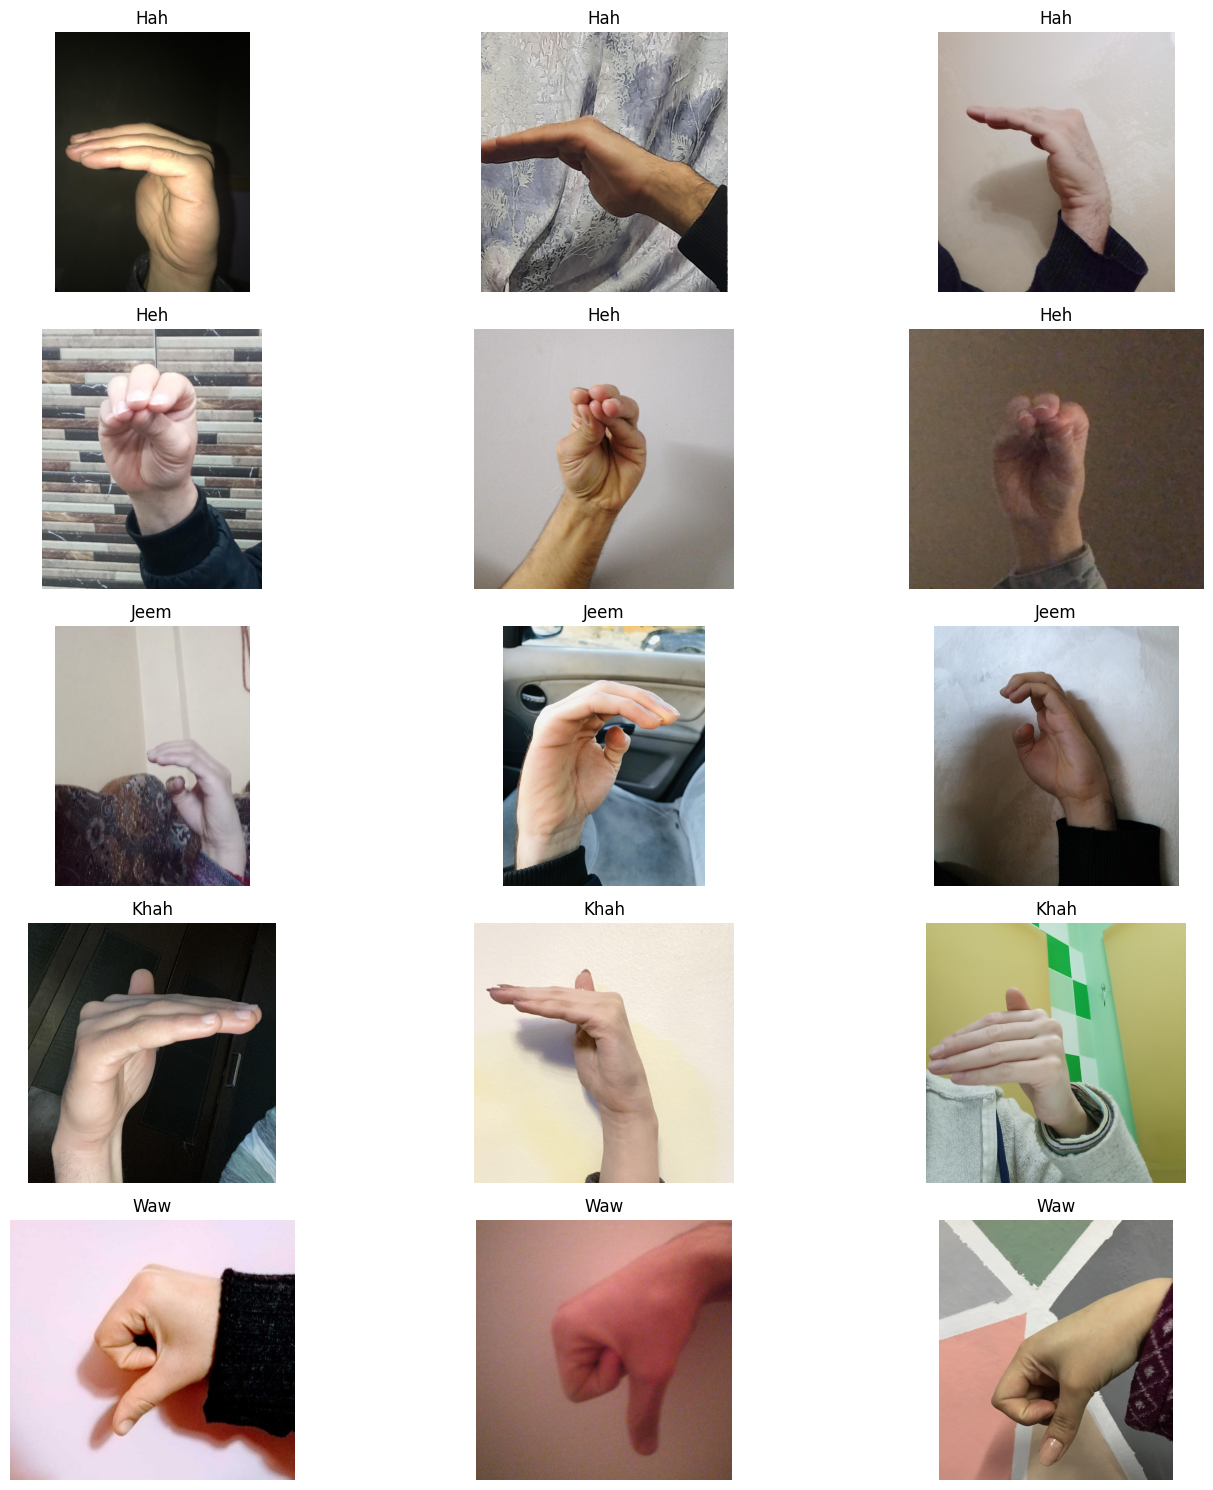

In [82]:
weak_samples = (
    train_data[
        train_data["label"].isin(problem_classes)
    ]
    .groupby("label", group_keys=False)
    .sample(n=3, random_state=42)
)

plt.figure(figsize=(15, 15))

for i, (_, row) in enumerate(
    weak_samples.iterrows()
):

    cropped = crop_hand(
        row["filepath"],
        scale=3.0
    )

    cropped_rgb = cv2.cvtColor(
        cropped,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(5, 3, i + 1)

    plt.imshow(cropped_rgb)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [83]:
import shutil
import os

# Remove crops created using the old detector
if os.path.exists(CROPPED_DIR):
    shutil.rmtree(CROPPED_DIR)

os.makedirs(CROPPED_DIR, exist_ok=True)

In [84]:
cropped_train_data = create_cropped_split(
    train_data,
    "train"
)

cropped_val_data = create_cropped_split(
    val_data,
    "validation"
)

cropped_test_data = create_cropped_split(
    test_data,
    "test"
)

train:   0%|          | 0/5499 [00:00<?, ?it/s]

validation:   0%|          | 0/1178 [00:00<?, ?it/s]

test:   0%|          | 0/1179 [00:00<?, ?it/s]

In [85]:
print(
    "Train detection rate:",
    cropped_train_data["hand_detected"].mean() * 100
)

print(
    "Validation detection rate:",
    cropped_val_data["hand_detected"].mean() * 100
)

print(
    "Test detection rate:",
    cropped_test_data["hand_detected"].mean() * 100
)

print("\nCounts:")
print("Train:", len(cropped_train_data))
print("Validation:", len(cropped_val_data))
print("Test:", len(cropped_test_data))

Train detection rate: 93.81705764684489
Validation detection rate: 94.14261460101866
Test detection rate: 94.65648854961832

Counts:
Train: 5499
Validation: 1178
Test: 1179


In [86]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_cropped_image(filepath, label):

    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize_with_pad(
        image,
        IMG_SIZE,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [87]:
def create_cropped_dataset(
    dataframe,
    shuffle=False
):

    filepaths = dataframe["filepath"].values
    labels = dataframe["label_id"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.map(
        load_cropped_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [88]:
cropped_train_ds = create_cropped_dataset(
    cropped_train_data,
    shuffle=True
)

cropped_val_ds = create_cropped_dataset(
    cropped_val_data
)

cropped_test_ds = create_cropped_dataset(
    cropped_test_data
)

In [89]:
for images, labels in cropped_train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:",
          tf.reduce_min(images).numpy(),
          tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 255.0


In [90]:
data_augmentation_v2 = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02),

    tf.keras.layers.RandomZoom(0.05),

    tf.keras.layers.RandomTranslation(
        height_factor=0.03,
        width_factor=0.03
    )
])

In [91]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model_v2 = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_v2.trainable = False

In [92]:
inputs = layers.Input(
    shape=(224, 224, 3)
)

x = data_augmentation_v2(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(
    x
)

x = base_model_v2(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model_v2 = models.Model(
    inputs,
    outputs
)

In [93]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [94]:
v2_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cropped_mobilenet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

v2_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

In [95]:
history_v2 = model_v2.fit(
    cropped_train_ds,
    validation_data=cropped_val_ds,
    epochs=8,
    callbacks=[
        v2_checkpoint,
        v2_early_stop
    ]
)

Epoch 1/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1574 - loss: 3.1388
Epoch 1: val_accuracy improved from None to 0.39559, saving model to best_cropped_mobilenet.keras

Epoch 1: finished saving model to best_cropped_mobilenet.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.2584 - loss: 2.6565 - val_accuracy: 0.3956 - val_loss: 2.0730
Epoch 2/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4533 - loss: 1.8308
Epoch 2: val_accuracy improved from 0.39559 to 0.46350, saving model to best_cropped_mobilenet.keras

Epoch 2: finished saving model to best_cropped_mobilenet.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.4890 - loss: 1.7378 - val_accuracy: 0.4635 - val_loss: 1.7160
Epoch 3/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5698 - loss: 1.4549
Epoch 3: val_accuracy improved from 0.46350 to 0.51358, saving model to best_cropped_mobilenet.keras

Epoch 3: finished saving model to best_cropped_mobilenet.keras
172/172 ━━━━━━━━━━━━

In [96]:
model_v2.save(
    "cropped_mobilenet_frozen_best.keras"
)

In [97]:
base_model_v2.trainable = True

for layer in base_model_v2.layers[:-30]:
    layer.trainable = False

In [98]:
for layer in base_model_v2.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

In [99]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [100]:
v2_ft_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cropped_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

v2_ft_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

v2_ft_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [101]:
history_v2_ft = model_v2.fit(
    cropped_train_ds,
    validation_data=cropped_val_ds,
    initial_epoch=8,
    epochs=20,
    callbacks=[
        v2_ft_checkpoint,
        v2_ft_early_stop,
        v2_ft_reduce_lr
    ]
)

Epoch 9/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.7818 - loss: 0.7287
Epoch 9: val_accuracy improved from None to 0.65874, saving model to best_cropped_finetuned.keras

Epoch 9: finished saving model to best_cropped_finetuned.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.7916 - loss: 0.6861 - val_accuracy: 0.6587 - val_loss: 1.0750 - learning_rate: 1.0000e-05
Epoch 10/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.8314 - loss: 0.5372
Epoch 10: val_accuracy improved from 0.65874 to 0.69185, saving model to best_cropped_finetuned.keras

Epoch 10: finished saving model to best_cropped_finetuned.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.8312 - loss: 0.5418 - val_accuracy: 0.6919 - val_loss: 0.9622 - learning_rate: 1.0000e-05
Epoch 11/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 985ms/step - accuracy: 0.8427 - loss: 0.5021
Epoch 11: val_accuracy improved from 0.69185 to 0.70458, saving model to best_cropped_finetuned.keras

Epoch 11: 

In [104]:
keras_files = glob.glob("*.keras")

print("Models found:")
for file in keras_files:
    print(file)

for file in keras_files:
    destination = os.path.join(
        MODEL_DIR,
        os.path.basename(file)
    )

    shutil.copy2(file, destination)

    print("Saved:", destination)

Models found:
best_stage2_arabic_sign_model.keras
arabic_sign_before_finetuning.keras
best_cropped_finetuned.keras
arabic_sign_stage1_80percent.keras
best_finetuned_arabic_sign_model.keras
cropped_mobilenet_frozen_best.keras
best_cropped_mobilenet.keras
Saved: /content/drive/MyDrive/ArabicSignProject/models/best_stage2_arabic_sign_model.keras
Saved: /content/drive/MyDrive/ArabicSignProject/models/arabic_sign_before_finetuning.keras
Saved: /content/drive/MyDrive/ArabicSignProject/models/best_cropped_finetuned.keras
Saved: /content/drive/MyDrive/ArabicSignProject/models/arabic_sign_stage1_80percent.keras
Saved: /content/drive/MyDrive/ArabicSignProject/models/best_finetuned_arabic_sign_model.keras
Saved: /content/drive/MyDrive/ArabicSignProject/models/cropped_mobilenet_frozen_best.keras
Saved: /content/drive/MyDrive/ArabicSignProject/models/best_cropped_mobilenet.keras


In [105]:
import os
import tensorflow as tf
import numpy as np

MODEL_DIR = "/content/drive/MyDrive/ArabicSignProject/models"

original_model = tf.keras.models.load_model(
    os.path.join(
        MODEL_DIR,
        "best_stage2_arabic_sign_model.keras"
    )
)

cropped_model = tf.keras.models.load_model(
    os.path.join(
        MODEL_DIR,
        "best_cropped_finetuned.keras"
    )
)

print("Both models loaded!")

Both models loaded!


In [106]:
original_probs = original_model.predict(
    val_ds,
    verbose=1
)

cropped_probs = cropped_model.predict(
    cropped_val_ds,
    verbose=1
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 44s 984ms/step


In [107]:
y_val_true = np.concatenate([
    labels.numpy()
    for images, labels in val_ds
])

In [108]:
from sklearn.metrics import accuracy_score

best_accuracy = 0
best_original_weight = 0

for w in np.arange(0.0, 1.01, 0.1):

    combined = (
        w * original_probs +
        (1 - w) * cropped_probs
    )

    predictions = np.argmax(
        combined,
        axis=1
    )

    accuracy = accuracy_score(
        y_val_true,
        predictions
    )

    print(
        f"Original {w:.1f} + "
        f"Cropped {1-w:.1f} = "
        f"{accuracy*100:.2f}%"
    )

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_original_weight = w

print("\nBEST:")
print("Original weight:", best_original_weight)
print("Cropped weight:", 1-best_original_weight)
print("Accuracy:", best_accuracy * 100)

Original 0.0 + Cropped 1.0 = 78.86%
Original 0.1 + Cropped 0.9 = 80.05%
Original 0.2 + Cropped 0.8 = 81.58%
Original 0.3 + Cropped 0.7 = 82.77%
Original 0.4 + Cropped 0.6 = 84.13%
Original 0.5 + Cropped 0.5 = 85.14%
Original 0.6 + Cropped 0.4 = 85.82%
Original 0.7 + Cropped 0.3 = 85.40%
Original 0.8 + Cropped 0.2 = 83.79%
Original 0.9 + Cropped 0.1 = 82.85%
Original 1.0 + Cropped 0.0 = 82.26%

BEST:
Original weight: 0.6000000000000001
Cropped weight: 0.3999999999999999
Accuracy: 85.82342954159593


In [109]:
import json
import os

ensemble_info = {
    "original_weight": 0.6,
    "cropped_weight": 0.4,
    "validation_accuracy": 0.8582342954159593
}

with open(
    os.path.join(MODEL_DIR, "ensemble_config.json"),
    "w"
) as f:
    json.dump(ensemble_info, f, indent=4)

print("Ensemble configuration saved!")

Ensemble configuration saved!


In [110]:
import matplotlib.pyplot as plt

train_acc = (
    history_v2.history["accuracy"] +
    history_v2_ft.history["accuracy"]
)

val_acc = (
    history_v2.history["val_accuracy"] +
    history_v2_ft.history["val_accuracy"]
)

train_loss = (
    history_v2.history["loss"] +
    history_v2_ft.history["loss"]
)

val_loss = (
    history_v2.history["val_loss"] +
    history_v2_ft.history["val_loss"]
)

epochs = range(1, len(train_acc) + 1)

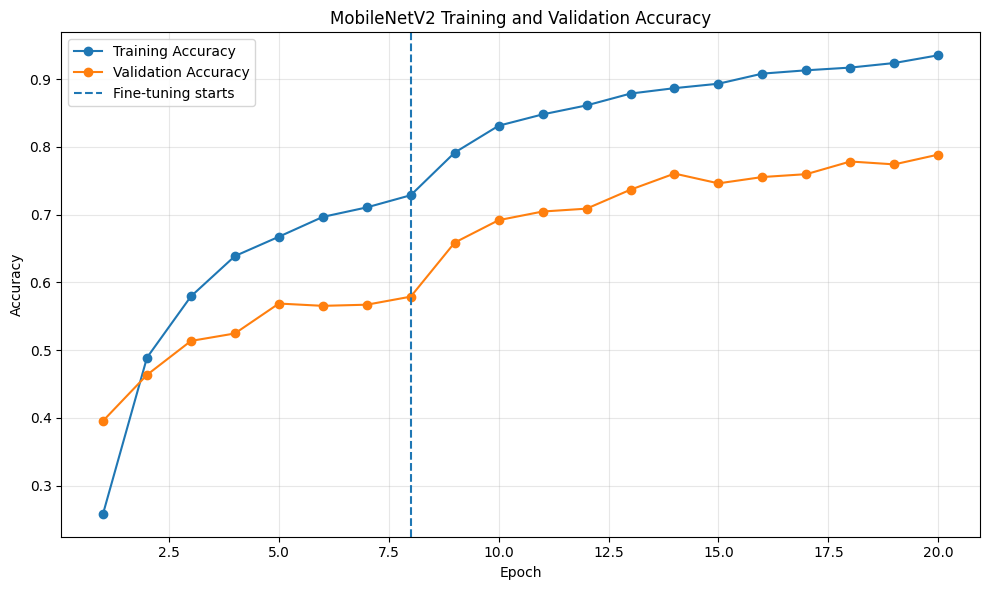

In [111]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_acc,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_acc,
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=8,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/ArabicSignProject/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

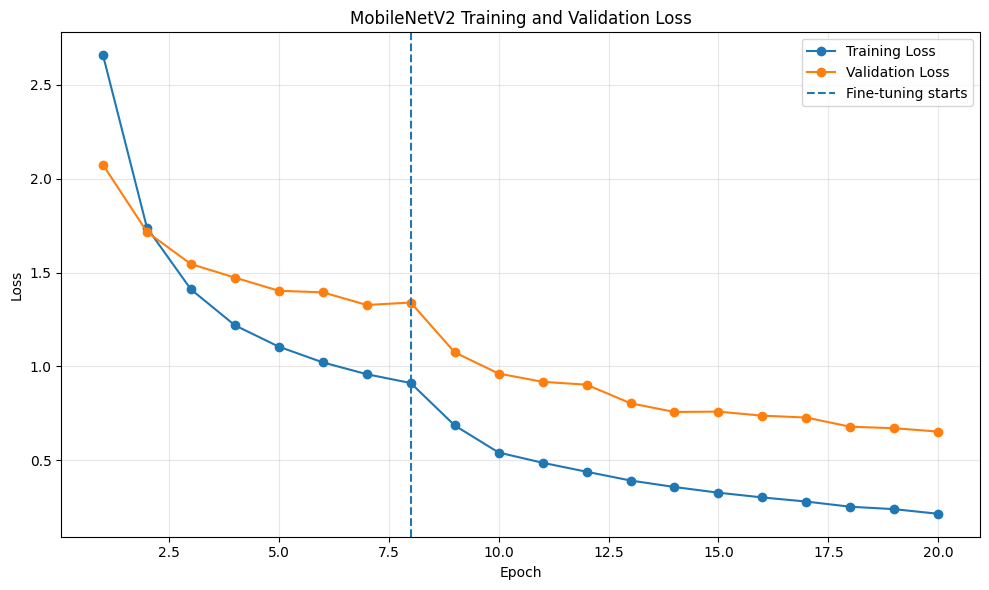

In [112]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    x=8,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/ArabicSignProject/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

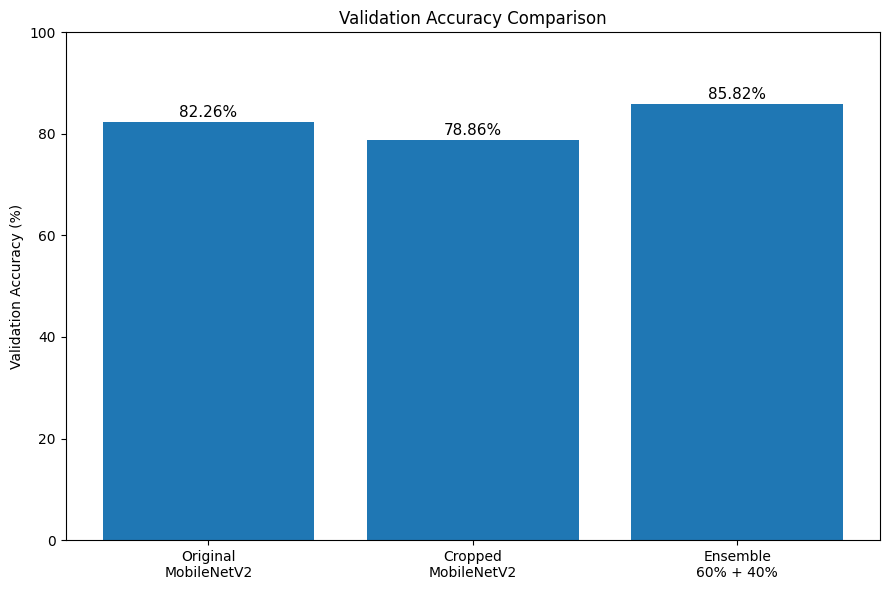

In [113]:
models = [
    "Original\nMobileNetV2",
    "Cropped\nMobileNetV2",
    "Ensemble\n60% + 40%"
]

accuracies = [
    82.26,
    78.86,
    85.82
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    models,
    accuracies
)

plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison")
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{acc:.2f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/ArabicSignProject/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [114]:
original_test_probs = original_model.predict(
    test_ds,
    verbose=1
)

cropped_test_probs = cropped_model.predict(
    cropped_test_ds,
    verbose=1
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step  


In [115]:
ensemble_test_probs = (
    0.6 * original_test_probs +
    0.4 * cropped_test_probs
)

y_test_pred = np.argmax(
    ensemble_test_probs,
    axis=1
)

In [116]:
y_test_true = np.concatenate([
    labels.numpy()
    for images, labels in test_ds
])

In [117]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(
    y_test_true,
    y_test_pred
)

print(
    f"FINAL TEST ACCURACY: "
    f"{test_accuracy * 100:.2f}%"
)

FINAL TEST ACCURACY: 86.34%


In [118]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=class_names,
    digits=3
)

print(report)

              precision    recall  f1-score   support

         Ain      0.875     0.972     0.921        36
          Al      0.925     0.881     0.902        42
        Alef      0.933     0.977     0.955        43
         Beh      0.816     0.870     0.842        46
         Dad      0.864     0.950     0.905        40
         Dal      0.722     0.743     0.732        35
         Feh      0.784     0.763     0.773        38
       Ghain      0.882     0.882     0.882        34
         Hah      0.780     0.865     0.821        37
         Heh      0.906     0.763     0.829        38
        Jeem      0.929     0.839     0.881        31
         Kaf      0.872     0.850     0.861        40
        Khah      0.935     0.763     0.841        38
         Laa      1.000     0.750     0.857        40
         Lam      0.735     0.923     0.818        39
        Meem      0.810     0.895     0.850        38
        Noon      0.875     0.800     0.836        35
         Qaf      0.700    

In [119]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

final_precision = precision_score(
    y_test_true,
    y_test_pred,
    average="weighted"
)

final_recall = recall_score(
    y_test_true,
    y_test_pred,
    average="weighted"
)

final_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="weighted"
)

print("FINAL MODEL RESULTS")
print("----------------------")
print(f"Accuracy : {test_accuracy * 100:.2f}%")
print(f"Precision: {final_precision * 100:.2f}%")
print(f"Recall   : {final_recall * 100:.2f}%")
print(f"F1 Score : {final_f1 * 100:.2f}%")

FINAL MODEL RESULTS
----------------------
Accuracy : 86.34%
Precision: 87.00%
Recall   : 86.34%
F1 Score : 86.33%


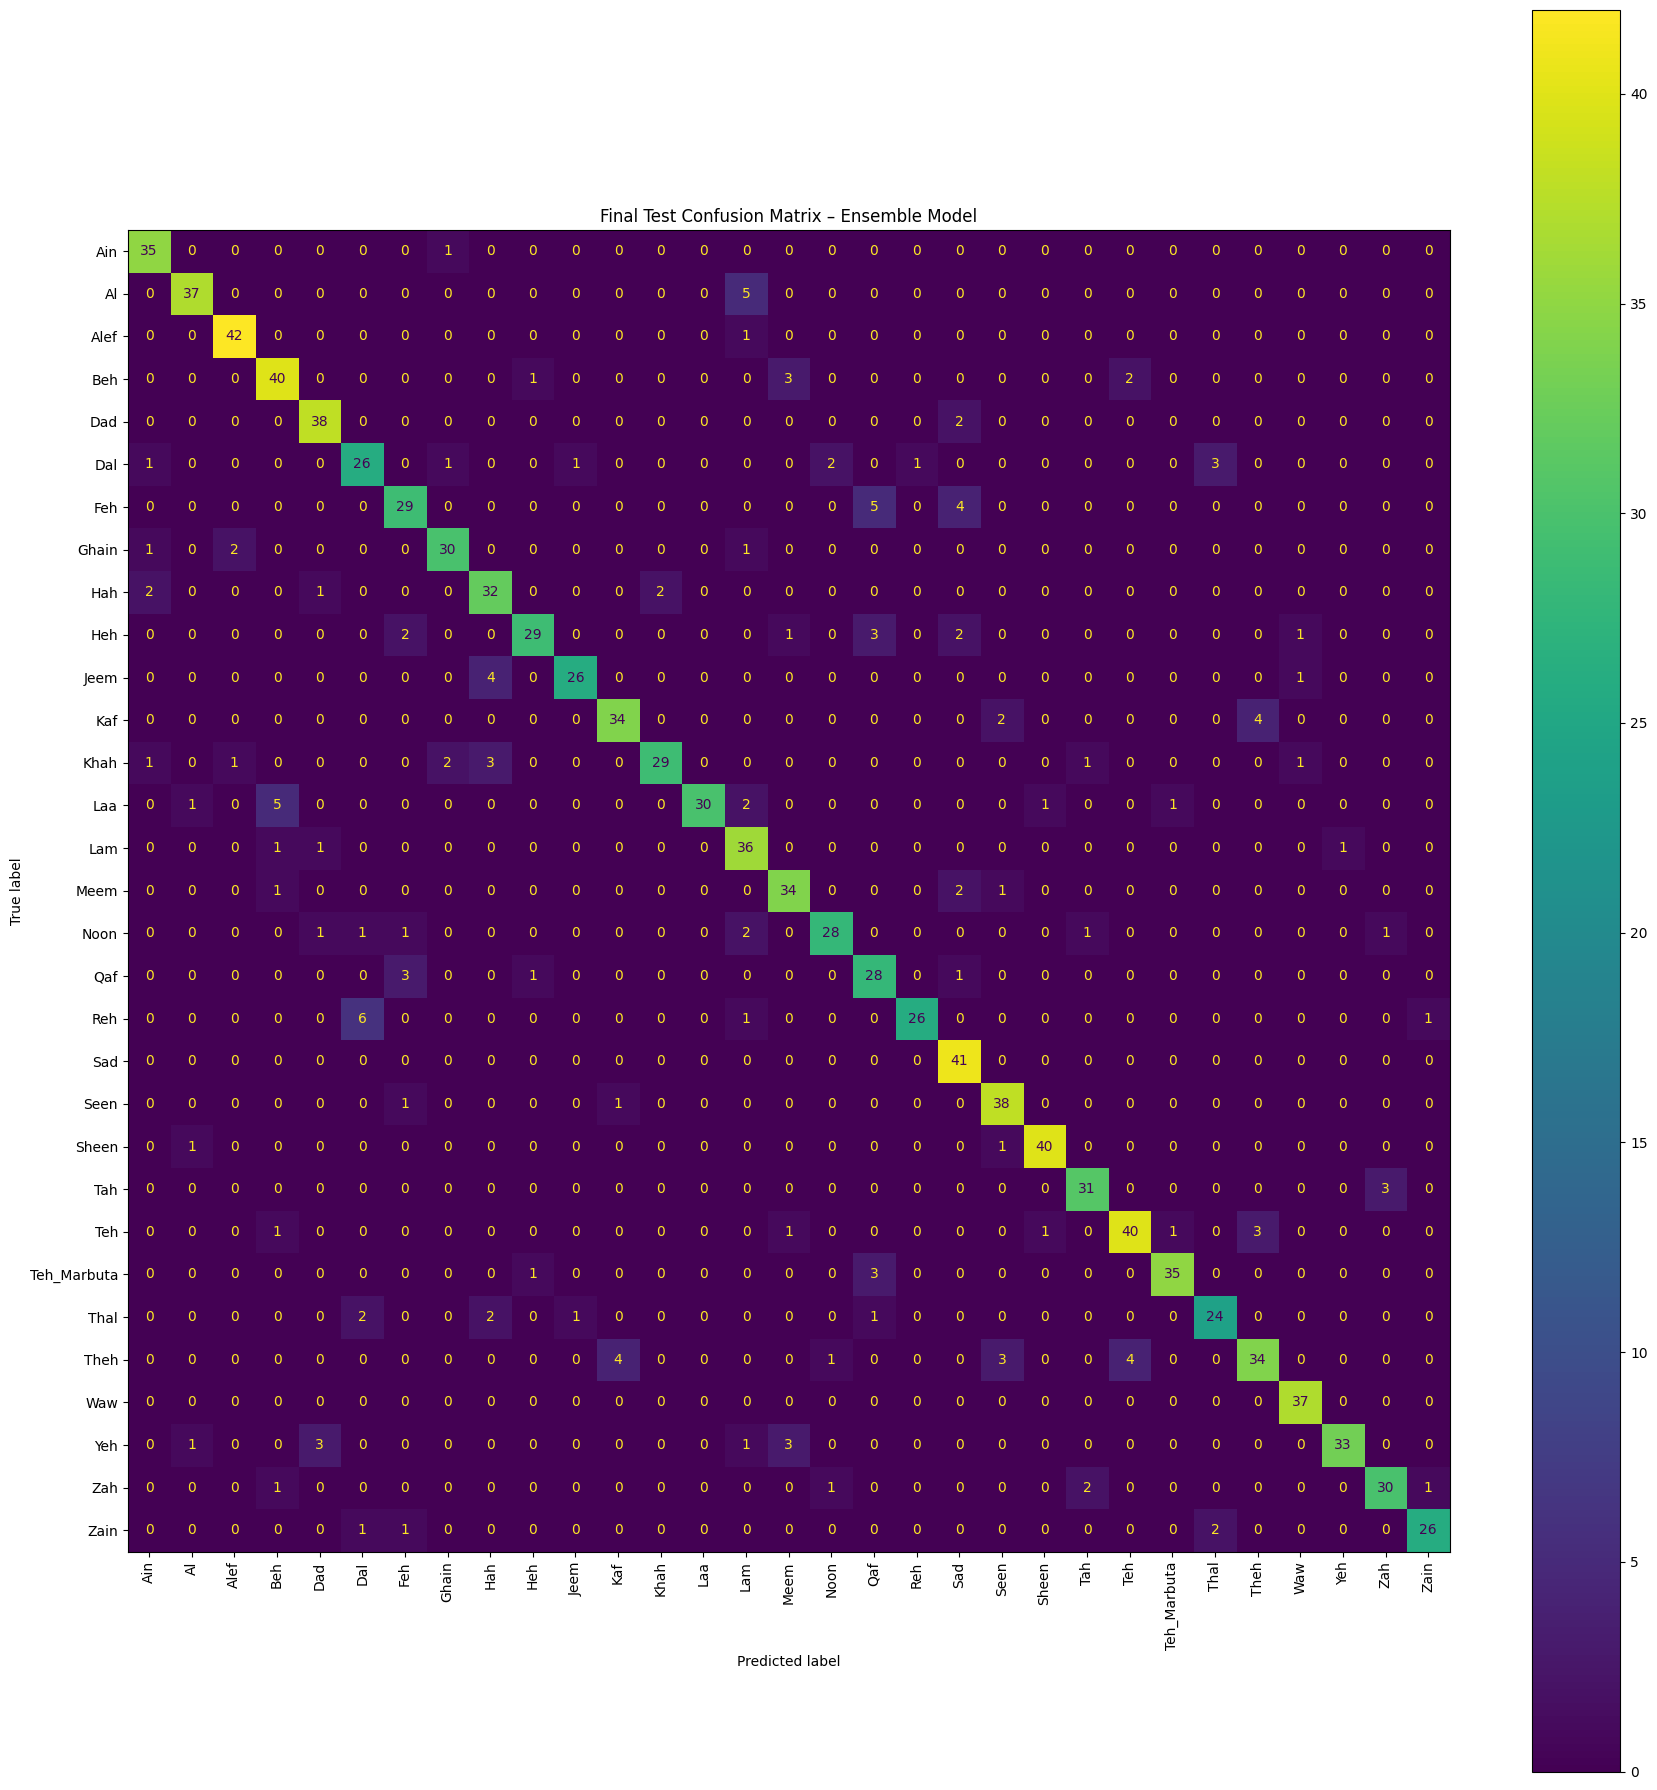

In [120]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm_test = confusion_matrix(
    y_test_true,
    y_test_pred
)

fig, ax = plt.subplots(
    figsize=(18, 18)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title(
    "Final Test Confusion Matrix – Ensemble Model"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/ArabicSignProject/test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [121]:
import os
import zipfile

MODEL_DIR = "/content/drive/MyDrive/ArabicSignProject/models"
ZIP_PATH = "/content/ArabicSignCameraModels.zip"

files_to_export = [
    "best_stage2_arabic_sign_model.keras",
    "best_cropped_finetuned.keras",
    "class_names.json",
    "ensemble_config.json"
]

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for filename in files_to_export:

        filepath = os.path.join(
            MODEL_DIR,
            filename
        )

        if os.path.exists(filepath):

            zipf.write(
                filepath,
                arcname=filename
            )

            print("Added:", filename)

        else:
            print("MISSING:", filename)

print("\nZIP created:", ZIP_PATH)

Added: best_stage2_arabic_sign_model.keras
Added: best_cropped_finetuned.keras
MISSING: class_names.json
Added: ensemble_config.json

ZIP created: /content/ArabicSignCameraModels.zip


In [122]:
from google.colab import files

files.download(
    "/content/ArabicSignCameraModels.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [123]:
import os
import json

PROJECT_DIR = "/content/drive/MyDrive/ArabicSignProject"
os.makedirs(PROJECT_DIR, exist_ok=True)

final_results = {
    "validation_accuracy": 85.8234,
    "test_accuracy": 86.34,
    "precision": 87.00,
    "recall": 86.34,
    "f1_score": 86.33,
    "original_model_weight": 0.6,
    "cropped_model_weight": 0.4
}

with open(
    os.path.join(PROJECT_DIR, "final_results.json"),
    "w"
) as f:
    json.dump(final_results, f, indent=4)

print("Final results saved.")

Final results saved.


In [124]:
with open(
    os.path.join(PROJECT_DIR, "classification_report.txt"),
    "w"
) as f:
    f.write(report)

print("Classification report saved.")

Classification report saved.
